# H₂O Casida TDDFT — Approach 1: High-level API

This notebook runs linear-response TDDFT (Casida equation) on a water molecule using the **one-shot** workflow:

1. QEpy ground-state SCF
2. `extract_casida_inputs_from_qepy_driver` → `CasidaInputs` + `CasidaOptions`
3. `run_casida_in_memory` → `CasidaResults`

For step-by-step control over matrix build and diagonalization, see **`h2o_tddft_approach2_stepwise.ipynb`**.

## Prerequisites

- `qepy`, `dftpy`, `casidapy`, `mpi4py` (optional), `matplotlib`
- Norm-conserving pseudopotentials in the notebook working directory:
  - `O_ONCV_PBE-1.2.upf`
  - `H_ONCV_PBE-1.2.upf`

In [2]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

from qepy.driver import Driver
from dftpy.field import DirectField

from casidapy.casida_api import CasidaOptions
from casidapy.casida_engine import run_casida_in_memory
from casidapy.qepy_adapter import extract_casida_inputs_from_qepy_driver

try:
    from mpi4py import MPI
    comm = MPI.COMM_WORLD
except ImportError:
    comm = None

HA_TO_EV = 27.211386245988

## 1. Ground-state SCF with QEpy

In [ ]:
# Fast tutorial SCF — lower cutoffs / looser conv than production (grid cost ~ ecutrho)
qe_options = {
    "&control": {
        "calculation": "'scf'",
        "pseudo_dir": "'./'",
        "verbosity": "'low'",
    },
    "&electrons": {
        "electron_maxstep": 80,
        "conv_thr": 1e-6,
        "mixing_beta": 0.6,
        "diagonalization": "'david'",
    },
    "&system": {
        "ibrav": 0,
        "nat": 3,
        "ntyp": 2,
        "ecutwfc": 35,
        "ecutrho": 140,
        "nbnd": 24,
        "nosym": True,
        "occupations": "'fixed'",
    },
    "atomic_species": [
        "O 15.999 O_ONCV_PBE-1.2.upf",
        "H 1.008 H_ONCV_PBE-1.2.upf",
    ],
    "atomic_positions": [
        "O  4.0  4.0  4.119262",
        "H  4.0  4.763239  3.522953",
        "H  4.0  3.236761  3.522953",
    ],
    "k_points automatic": ["1 1 1 0 0 0"],
    "cell_parameters angstrom": [
        "8.0  0.0  0.0",
        "0.0  8.0  0.0",
        "0.0  0.0  8.0",
    ],
}

driver = Driver(qe_options=qe_options, logfile=False)
scf_energy = driver.scf()
print(f"SCF energy (Ry): {scf_energy:.6f}")



In [4]:
HA_TO_EV = 27.211386245988
eig_ev = driver.get_eigenvalues() / 2.0 * HA_TO_EV
occs = driver.get_occupation_numbers()
n_occ = int((occs > 0.5).sum())

print("SCF converged? — check log for 'convergence has been achieved'")
for i in range(n_occ, min(n_occ + 8, len(eig_ev))):
    gap = eig_ev[i] - eig_ev[n_occ - 1]
    print(f"  band {i} (occ={occs[i]:.1f}): {eig_ev[i]:8.3f} eV,  Δε from HOMO = {gap:6.3f} eV")

SCF converged? — check log for 'convergence has been achieved'
  band 4 (occ=0.0):   -6.883 eV,  Δε from HOMO =  0.057 eV
  band 5 (occ=0.0):   -6.782 eV,  Δε from HOMO =  0.158 eV
  band 6 (occ=0.0):   -0.266 eV,  Δε from HOMO =  6.674 eV
  band 7 (occ=0.0):    0.701 eV,  Δε from HOMO =  7.642 eV
  band 8 (occ=0.0):    0.912 eV,  Δε from HOMO =  7.853 eV
  band 9 (occ=0.0):    1.034 eV,  Δε from HOMO =  7.974 eV
  band 10 (occ=0.0):    1.733 eV,  Δε from HOMO =  8.673 eV
  band 11 (occ=0.0):    2.069 eV,  Δε from HOMO =  9.010 eV


## 2. Package QE outputs for CasidaPy

Attach DFTpy grid objects to an ASE-like `atoms` container (same pattern as `test-h2o.ipynb`).

In [7]:
grid = driver.get_dftpy_grid()  # uses QE nr + ecutrho
nr = driver.get_number_of_grid_points()
print("QE grid nr:", nr, "  nnr:", int(np.prod(nr)))
rho_field = driver.data2field(driver.get_density(), grid=grid)
atoms = driver.get_ase_atoms()
#atoms = driver.get_ase_atoms()
atoms.pbc = True

atoms.grid = grid
atoms.ions = driver.get_dftpy_ions()
occs = driver.get_occupation_numbers()
print(f"Occupations (first 10): {occs[:10]}")
print(f"n occupied bands: {int(np.sum(occs > 0.5))}")

QE grid nr: [72 72 72]   nnr: 373248
Occupations (first 10): [2. 2. 2. 2. 0. 0. 0. 0. 0. 0.]
n occupied bands: 4


## 3. Extract Casida inputs and options

`extract_casida_inputs_from_qepy_driver` builds `CasidaInputs` (density, orbitals, eigenvalues) and default `CasidaOptions` (active space sizes, XC, solver flags).

In [9]:
casida_inputs, casida_options = extract_casida_inputs_from_qepy_driver(
    driver,
    atoms,
    grid,
    use_eDFTpy=False,
)

# Solver / active-space knobs
casida_options.n_states = 30
casida_options.n_unocc = 16
casida_options.tda = True
casida_options.matrix_free = False
casida_options.xc = "PBE"

# Skip unoccupied bands with Δε(HOMO) < 1 eV (box states); reindex eigs, psi, occs
eig_ha = np.asarray(casida_inputs.eigs, dtype=float)
eig_ev = eig_ha * HA_TO_EV
occs = np.asarray(casida_inputs.occs)
psi = np.asarray(casida_inputs.psi)

n_total_occ = int((occs > 0.5).sum())
e_homo_ev = eig_ev[n_total_occ - 1]
delta_lumo_min_ev = 1.0

occ_keep = list(range(n_total_occ))
i_lumo = next(
    i for i in range(n_total_occ, len(eig_ev))
    if eig_ev[i] - e_homo_ev >= delta_lumo_min_ev
)
unocc_keep = list(range(i_lumo, len(eig_ev)))
keep = occ_keep + unocc_keep

casida_inputs.eigs = eig_ha[keep]
casida_inputs.psi = psi[keep]
casida_inputs.occs = occs[keep]

casida_options.n_occ = len(occ_keep)
casida_options.n_unocc = min(casida_options.n_unocc, len(unocc_keep))
casida_options.n_total_occ = len(occ_keep)

print(f"Skipped unocc bands {list(range(n_total_occ, i_lumo))} (Δε_HOMO < {delta_lumo_min_ev} eV)")
print(f"First unocc: band {i_lumo}, Δε_HOMO = {eig_ev[i_lumo] - e_homo_ev:.3f} eV")
print(casida_options)

[2. 2. 2. 2. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]
CasidaOptions(n_occ=4, n_unocc=16, n_states=30, n_total_occ=None, tda=True, matrix_free=False, solver_method='lobpcg', solver_tol=1e-08, solver_maxiter=200, use_gpu=False, xc='PBE', spin_state='singlet', of_context=False, pseudo_map=None, use_uspp=False, uspp_map=None, use_eDFTpy=False, tag=None)


## 4. Run Casida TDDFT in one call

`run_casida_in_memory` handles orbital normalization, active-space slicing, matrix construction, diagonalization, and oscillator strengths.

In [10]:
results = run_casida_in_memory(casida_inputs, casida_options, comm=comm)

omega_ev = results.omega * HA_TO_EV
print(f"Computed {len(results.omega)} excitations")
print(f"Lowest excitation: {omega_ev[0]:.3f} eV")
print(f"Sum of oscillator strengths: {results.f.sum():.6f}")

N total occ 4
rank 0: len(eigs)=50, len(occs)=50, sum(occs>0.5)=4, n_total_occ(will use)=4, options n_occ=4 n_unocc=16
rank 0: len(psi_all)=50, n_o=4, n_u=16, Ntrans=64
Building Casida matrices: 4 occ x 16 unocc = 64 transitions
MPI ranks: 1 (CPU only)
  Rank 0: row 0/64
  Rank 0: row 10/64
  Rank 0: row 20/64
  Rank 0: row 30/64
  Rank 0: row 40/64
  Rank 0: row 50/64
  Rank 0: row 60/64
Matrix construction complete. C shape: (64, 64)
Computed 30 excitations
Lowest excitation: 0.120 eV
Sum of oscillator strengths: 1.000000


/Users/aniketmandal/prg_env/lib/python3.10/site-packages/casidapy/casida_engine.py:225: RuntimeWarning: divide by zero encountered in matmul
  d = mu.T @ self.Z
/Users/aniketmandal/prg_env/lib/python3.10/site-packages/casidapy/casida_engine.py:225: RuntimeWarning: overflow encountered in matmul
  d = mu.T @ self.Z
/Users/aniketmandal/prg_env/lib/python3.10/site-packages/casidapy/casida_engine.py:225: RuntimeWarning: invalid value encountered in matmul
  d = mu.T @ self.Z


## 5. Inspect and plot the absorption spectrum

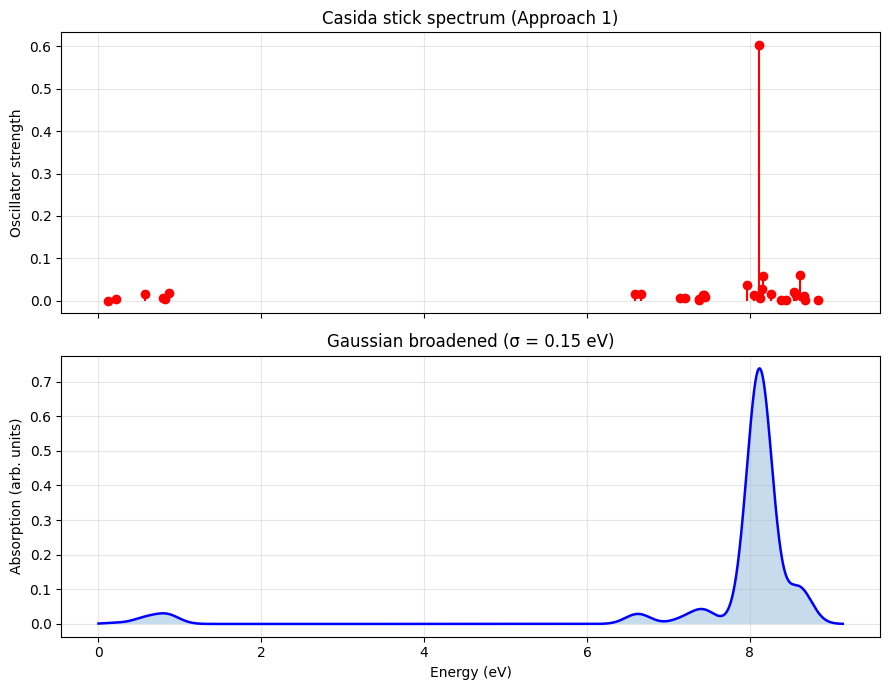

In [11]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

ax1.stem(omega_ev, results.f, basefmt=" ", markerfmt="ro", linefmt="r-")
ax1.set_ylabel("Oscillator strength")
ax1.set_title("Casida stick spectrum (Approach 1)")
ax1.grid(alpha=0.3)

sigma = 0.15  # eV Gaussian broadening
emin = max(0.0, omega_ev.min() - 2 * sigma)
emax = omega_ev.max() + 2 * sigma
grid_ev = np.linspace(emin, emax, 2000)
broadened = np.zeros_like(grid_ev)
for e, f in zip(omega_ev, results.f):
    broadened += f * np.exp(-0.5 * ((grid_ev - e) / sigma) ** 2)

ax2.plot(grid_ev, broadened, "b-", lw=1.8)
ax2.fill_between(grid_ev, broadened, alpha=0.25)
ax2.set_xlabel("Energy (eV)")
ax2.set_ylabel("Absorption (arb. units)")
ax2.set_title(f"Gaussian broadened (σ = {sigma} eV)")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

| Step | API |
|------|-----|
| QE → Casida packaging | `extract_casida_inputs_from_qepy_driver` |
| Solve + oscillator strengths | `run_casida_in_memory` |
| Output | `CasidaResults` (`omega`, `f`, `Z`, metadata) |

Use this path when you want a standard Casida workflow without managing individual solver stages.